<a href="https://colab.research.google.com/github/pimchayasupr-hash/CPE352-Anemia-Detection/blob/main/anemia_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1: การนำเข้าข้อมูลและสำรวจข้อมูลเบื้องต้น (Data Ingestion & Profiling)

--- 1. Data Ingestion & Profiling ---
Using Colab cache for faster access to the 'iron-deficiency-anemia-clinical-dataset' dataset.
ขนาดชุดข้อมูล (มิติ): (1000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Hemoglobin   1000 non-null   float64
 1   RDW          1000 non-null   float64
 2   MCV          1000 non-null   float64
 3   Age          1000 non-null   int64  
 4   Gender       1000 non-null   object 
 5   Anemia_Type  1000 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 47.0+ KB

ข้อมูลชนิดต่างๆ และค่าว่าง:
 None

สถิติเชิงพรรณนา:
         Hemoglobin          RDW          MCV          Age
count  1000.000000  1000.000000  1000.000000  1000.000000
mean     12.755300    14.145500    84.315000    48.402000
std       2.605548     1.675263     8.618099    18.032237
min       8.000000    11.500000    65.100000  

/tmp/ipykernel_11337/1635078764.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Anemia_Type', data=df, palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3656 (\N{THAI CHARAC

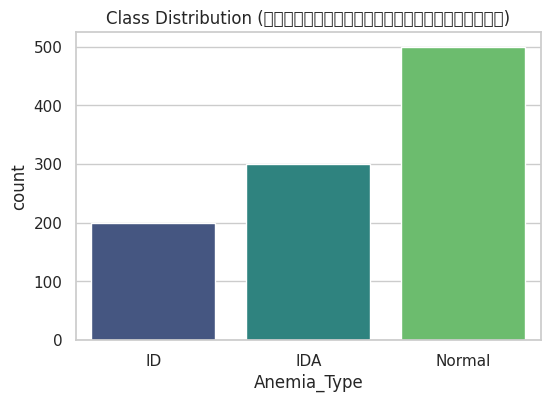

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

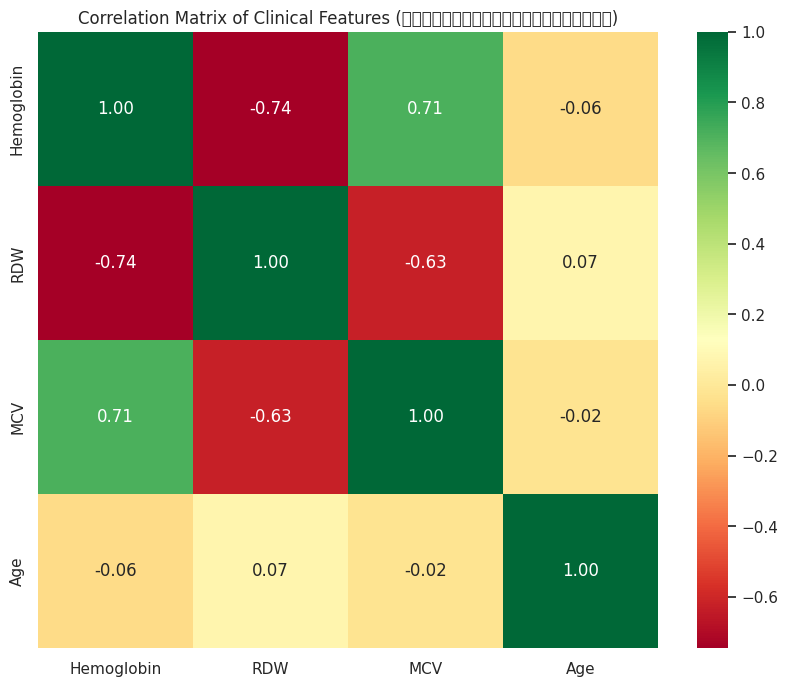

In [13]:
# ==========================================
# 1. Data Ingestion & Profiling (การนำเข้าและสำรวจข้อมูลเบื้องต้น)
# ==========================================
# ติดตั้งไลบรารีเพิ่มเติมสำหรับระบบอธิบายโมเดล (SHAP) และโมเดลขั้นสูง (XGBoost)
!pip install shap xgboost -q

# นำเข้าเครื่องมือพื้นฐานสำหรับจัดการข้อมูลและวาดกราฟ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

print("--- 1. Data Ingestion & Profiling ---")
# ดาวน์โหลดชุดข้อมูลจาก Kaggle อัตโนมัติ
dataset_path = kagglehub.dataset_download("zara2099/iron-deficiency-anemia-clinical-dataset")
df = pd.read_csv(os.path.join(dataset_path, "IDA_dataset.csv"))

# ตรวจสอบขนาดของตาราง (จำนวนแถว, จำนวนคอลัมน์)
print(f"ขนาดชุดข้อมูล (มิติ): {df.shape}")
# ตรวจสอบชนิดข้อมูลของแต่ละคอลัมน์และดูว่ามีค่าว่าง (Null) หรือไม่
print("\nข้อมูลชนิดต่างๆ และค่าว่าง:\n", df.info())
# ดูสถิติเชิงพรรณนาเบื้องต้น (เช่น ค่าเฉลี่ย, ค่าต่ำสุด, ค่าสูงสุด)
print("\nสถิติเชิงพรรณนา:\n", df.describe())

# ---------------- EDA (การวิเคราะห์ข้อมูลเชิงสำรวจ) ----------------
sns.set_theme(style="whitegrid")

# พล็อตกราฟแท่งเพื่อดูสัดส่วนของผู้ป่วยแต่ละคลาส
# *จุดประสงค์*: เพื่อเช็คว่าข้อมูลสมดุลหรือไม่ (ถ้าแท่งใดแท่งหนึ่งเตี้ยกว่าเพื่อนมาก แปลว่ามีปัญหา Imbalanced Data)
plt.figure(figsize=(6, 4))
sns.countplot(x='Anemia_Type', data=df, palette='viridis')
plt.title('Class Distribution (สัดส่วนของโรคในชุดข้อมูล)')
plt.show()

# พล็อตกราฟ Heatmap เพื่อดูความสัมพันธ์ (Correlation) ระหว่างตัวแปรตัวเลขทั้งหมด
# *จุดประสงค์*: ดูว่าค่าตัวแปรไหนแปรผันตามกัน (ค่าเข้าใกล้ 1) หรือสวนทางกัน (ค่าเข้าใกล้ -1)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Matrix of Clinical Features (ความสัมพันธ์ของตัวแปร)')
plt.show()

Cell 2: การเตรียมและทำความสะอาดข้อมูล (Data Preprocessing)

In [23]:
# ==========================================
# 2. Data Preprocessing (การเตรียมและทำความสะอาดข้อมูล)
# ==========================================
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

print("--- 2. Data Preprocessing ---")

# ---------------------------------------------------------
# 2.1 Categorical Encoding: การแปลงข้อมูลตัวอักษรเป็นตัวเลข
# ---------------------------------------------------------
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print("แปลงข้อมูล 'Gender' เป็นตัวเลขเรียบร้อย")

# ---------------------------------------------------------
# 2.2 Missing Value Handling: เติมค่าว่างด้วย KNN Imputer
# ---------------------------------------------------------
imputer = KNNImputer(n_neighbors=5)
# เราต้องดึงคอลัมน์เฉลย ('Anemia_Type') ออกก่อน เพื่อไม่ให้มันแอบดูเฉลยตอนคำนวณเติมค่า
X_imputed = imputer.fit_transform(df.drop('Anemia_Type', axis=1))

# นำข้อมูลที่เติมค่าว่างเสร็จแล้ว กลับมาสร้างเป็นตาราง DataFrame ตามเดิม
df_clean = pd.DataFrame(X_imputed, columns=df.drop('Anemia_Type', axis=1).columns)
# เอาคอลัมน์เฉลยกลับมาแปะคืน
df_clean['Anemia_Type'] = df['Anemia_Type'].values

# ---------------------------------------------------------
# 2.3 Outlier Treatment: ตัดค่าผิดปกติด้วยหลักการ IQR
# ---------------------------------------------------------
def remove_outliers_iqr(data, columns):
    for col in columns:
        Q1 = data[col].quantile(0.25) # ค่าที่ตำแหน่ง 25% (ควอไทล์ที่ 1)
        Q3 = data[col].quantile(0.75) # ค่าที่ตำแหน่ง 75% (ควอไทล์ที่ 3)
        IQR = Q3 - Q1 # ระยะห่างระหว่าง Q1 ถึง Q3
        lower_bound = Q1 - 1.5 * IQR # กำหนดเส้นขอบเขตล่าง
        upper_bound = Q3 + 1.5 * IQR # กำหนดเส้นขอบเขตบน

        # เก็บไว้เฉพาะแถวที่ข้อมูลอยู่ในขอบเขต
        data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return data

# ใช้คำสั่ง .str.strip() เพื่อลบ "ช่องว่าง" ที่แอบซ่อนอยู่หน้าหรือหลังชื่อคอลัมน์ทิ้ง (แก้ KeyError)
df_clean.columns = df_clean.columns.str.strip()

# กำหนดรายชื่อคอลัมน์ค่าเลือดสำคัญที่เราต้องการตรวจสอบ Outlier
numeric_cols = ['Hemoglobin', 'Serum Ferritin', 'MCV', 'MCH', 'MCHC']

# เช็คให้ชัวร์ว่าคอลัมน์เหล่านั้น "มีอยู่จริง" ในตาราง ป้องกันปัญหา KeyError
numeric_cols_exist = [col for col in numeric_cols if col in df_clean.columns]

# นำข้อมูลไปผ่านฟังก์ชันตัด Outlier
df_final = remove_outliers_iqr(df_clean, numeric_cols_exist)
print(f"จำนวนแถวหลังจากตัด Outlier ออก: {df_final.shape[0]} แถว")

# ---------------------------------------------------------
# 2.4 เตรียมแยกข้อมูลเข้าสู่กระบวนการ Train
# ---------------------------------------------------------
# X คือ "ข้อสอบ" (Features) ที่ให้ AI เรียนรู้ จึงต้องดึงคอลัมน์เฉลยออก
X = df_final.drop('Anemia_Type', axis=1)

# y คือ "เฉลย" (Target) ที่เราต้องการให้ AI ทายให้ถูก
y = df_final['Anemia_Type']

--- 2. Data Preprocessing ---
แปลงข้อมูล 'Gender' เป็นตัวเลขเรียบร้อย
จำนวนแถวหลังจากตัด Outlier ออก: 1000 แถว


Cell 3: การแบ่งข้อมูลและจัดการสัดส่วน (Data Splitting & Resampling)

In [16]:
# ==========================================
# 3. Data Splitting & Resampling (การแบ่งข้อมูลและจัดการสัดส่วน)
# ==========================================
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("--- 3. Data Splitting & Resampling ---")

# 3.1 Train-Test Split: แบ่งชุดข้อมูลเรียน (Train 80%) และสอบ (Test 20%)
# *จุดประสงค์*: stratify=y คือการบังคับให้สัดส่วนของโรคทั้ง 3 ชนิด กระจายเท่าๆ กันในชุด Train และ Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3.2 Feature Scaling: การปรับสเกลตัวเลขให้ขอบเขตเท่ากัน (Standardization)
# *จุดประสงค์*: ป้องกันไม่ให้ AI เทน้ำหนักไปที่ตัวแปรที่มีค่าหลักแสน (เช่น เม็ดเลือด) มากกว่าตัวแปรหลักสิบ (เช่น อายุ)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # ชุด Train ให้เรียนรู้ค่าและปรับสเกล
X_test_scaled = scaler.transform(X_test)       # ชุด Test ให้ปรับสเกลอย่างเดียว (ห้ามเรียนรู้ใหม่)

# 3.3 Handling Imbalanced Data: แก้ปัญหาคนป่วยน้อยกว่าคนปกติด้วย SMOTE
# *จุดประสงค์*: จำลองข้อมูลคนป่วยเพิ่มขึ้นมาทางคณิตศาสตร์ให้เท่ากับคนปกติ (ทำเฉพาะในชุด Train เท่านั้น!)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"ขนาดชุดข้อมูล Train ก่อนทำ SMOTE: {X_train.shape[0]} แถว")
print(f"ขนาดชุดข้อมูล Train หลังทำ SMOTE: {X_train_resampled.shape[0]} แถว (สมดุลแล้ว)")

--- 3. Data Splitting & Resampling ---
ขนาดชุดข้อมูล Train ก่อนทำ SMOTE: 800 แถว
ขนาดชุดข้อมูล Train หลังทำ SMOTE: 1200 แถว (สมดุลแล้ว)


Cell 4: การสร้างและฝึกสอนโมเดล (Modeling & Hyperparameter Tuning)

In [17]:
# ==========================================
# 4. Modeling & Hyperparameter Tuning (การสร้างและฝึกสอนโมเดล)
# ==========================================
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

print("--- 4. Modeling ---")

# 4.1 Baseline Model: โมเดลพื้นฐาน (Logistic Regression)
# *จุดประสงค์*: สร้างโมเดลแบบง่ายๆ ขึ้นมาก่อน เพื่อเอาไว้เป็นไม้บรรทัดวัดว่าโมเดลขั้นสูงของเราดีกว่าแค่ไหน
baseline = LogisticRegression(class_weight='balanced', random_state=42)
baseline.fit(X_train_resampled, y_train_resampled)
print("ฝึกสอนโมเดล Baseline (Logistic Regression) สำเร็จ!")

# --- เตรียมข้อมูลสำหรับ XGBoost ---
# XGBoost ต้องการให้เฉลย (y) เป็นตัวเลข (เช่น 0, 1, 2) จึงต้องใช้ LabelEncoder แปลงก่อน
le_y = LabelEncoder()
y_train_encoded = le_y.fit_transform(y_train_resampled)
y_test_encoded = le_y.transform(y_test)

# 4.2 Advanced Model: โมเดลขั้นสูง (XGBoost) ร่วมกับการจูนพารามิเตอร์ (GridSearchCV)
xgb = XGBClassifier(random_state=42)

# กำหนดสเปค (Parameters) ที่อยากให้ระบบสุ่มทดสอบหาค่าที่ดีที่สุด
param_grid = {
    'n_estimators': [50, 100],      # จำนวนต้นไม้ที่จะสร้าง
    'learning_rate': [0.01, 0.1],   # ความเร็วในการเรียนรู้
    'max_depth': [3, 5]             # ความลึกของต้นไม้ (ลึกไปจะเกิด Overfitting)
}

# GridSearchCV: ให้คอมพิวเตอร์นำสเปคด้านบนมาทดสอบสลับจับคู่กันทั้งหมดแบบอัตโนมัติ (Cross-Validation 5 รอบ)
print("กำลังค้นหาพารามิเตอร์ที่ดีที่สุดสำหรับ XGBoost (Hyperparameter Tuning)...")
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='f1_macro')
grid_search.fit(X_train_resampled, y_train_encoded)

# ดึงโมเดลเวอร์ชันที่ตั้งค่าได้เก่งที่สุดออกมา
best_model = grid_search.best_estimator_
print(f"พารามิเตอร์ที่ดีที่สุดที่ระบบค้นพบ: {grid_search.best_params_}")

--- 4. Modeling ---
ฝึกสอนโมเดล Baseline (Logistic Regression) สำเร็จ!
กำลังค้นหาพารามิเตอร์ที่ดีที่สุดสำหรับ XGBoost (Hyperparameter Tuning)...
พารามิเตอร์ที่ดีที่สุดที่ระบบค้นพบ: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


Cell 5: การประเมินและการอธิบายโมเดล (Evaluation & Explainability)

--- 5. Evaluation & Explainability ---
ความแม่นยำรวม (Accuracy): 99.50%

รายงานประเมินผลอย่างละเอียด (Classification Report):
              precision    recall  f1-score   support

          ID       1.00      0.97      0.99        40
         IDA       0.98      1.00      0.99        60
      Normal       1.00      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

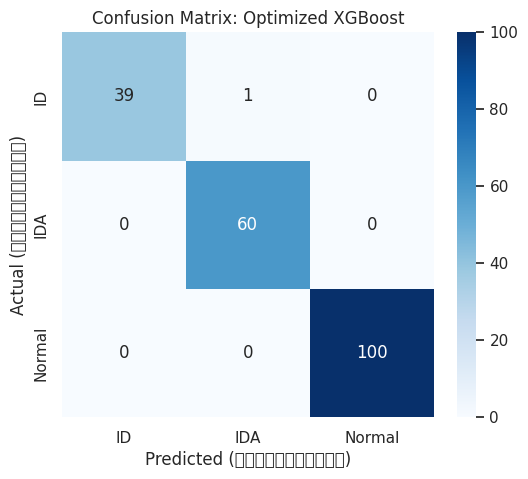


กำลังคำนวณ SHAP Values เพื่อหาความสำคัญของตัวแปร...

SHAP Summary Plot (ปัจจัยที่มีอิทธิพลต่อการตัดสินใจของโมเดล):


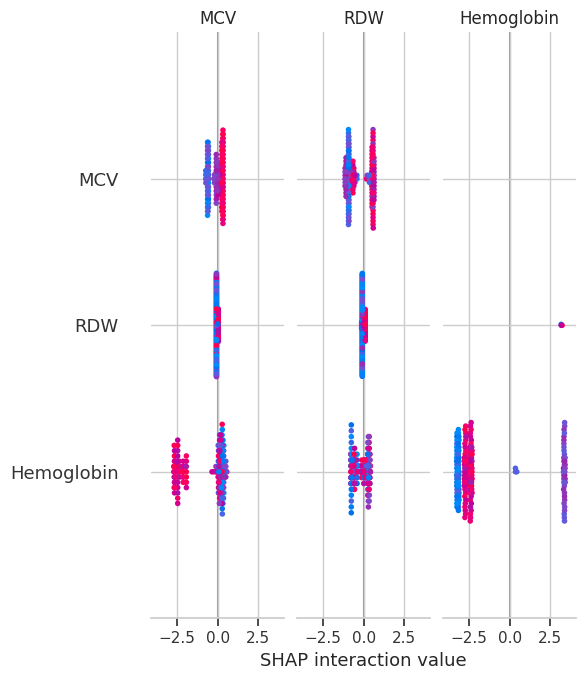

In [18]:
# ==========================================
# 5. Evaluation & Explainability (การประเมินและการอธิบายโมเดล)
# ==========================================
import shap
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("--- 5. Evaluation & Explainability ---")

# ให้สุดยอดโมเดลของเรา (XGBoost ที่จูนแล้ว) ลองทำข้อสอบ (Test)
y_pred = best_model.predict(X_test_scaled)

# 5.1 ตัวชี้วัดประสิทธิภาพ (Performance Metrics)
# *จุดประสงค์*: ดูความแม่นยำรวม และดูรายโรค (เน้นดูค่า Recall ว่าหาคนป่วยเจอครบไหม)
print(f"ความแม่นยำรวม (Accuracy): {accuracy_score(y_test_encoded, y_pred)*100:.2f}%\n")
print("รายงานประเมินผลอย่างละเอียด (Classification Report):")
print(classification_report(y_test_encoded, y_pred, target_names=le_y.classes_))

# 5.2 กราฟเมทริกซ์ความสับสน (Confusion Matrix)
# *จุดประสงค์*: ดูว่าโมเดลทายถูกกี่คน และ "สับสน" ทายโรคผิดไปกี่คน
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_encoded, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.title('Confusion Matrix: Optimized XGBoost')
plt.xlabel('Predicted (โมเดลทายว่า)')
plt.ylabel('Actual (ของจริงเป็น)')
plt.show()

# 5.3 Model Interpretability (การอธิบายเหตุผลของ AI ด้วย SHAP Values)
# *จุดประสงค์*: ทลาย "กล่องดำ" ของ AI กราฟนี้จะอธิบายให้แพทย์ฟังได้ว่า ตัวแปรคลินิกตัวไหน (เช่น Hemoglobin ต่ำ) ทำให้ AI ตัดสินใจว่าเป็นโรคโลหิตจาง
print("\nกำลังคำนวณ SHAP Values เพื่อหาความสำคัญของตัวแปร...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

print("\nSHAP Summary Plot (ปัจจัยที่มีอิทธิพลต่อการตัดสินใจของโมเดล):")
# วาดกราฟสรุป (ใช้ X_test ที่เป็น DataFrame เพื่อให้กราฟแสดงชื่อคอลัมน์ได้ถูกต้อง)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)